In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pylab as plt

In [19]:
# data distributions...
batch_size = 32
dataset_size = 200
mean_centers = torch.tensor([ 
                [1, 0.5], 
                [1, -0.5], 
                # [-1, 0.5], 
                # [-1, -0.5]
                ])
num_modes = mean_centers.shape[0]
data_dist = mean_centers[torch.randint(num_modes, (dataset_size, ))] + torch.randn(dataset_size, 2)*0.1
gen_dist = torch.randn(batch_size, 2)*0.6

(-2.0, 2.0)

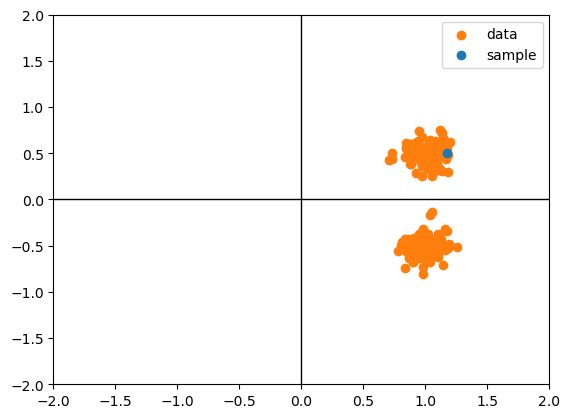

In [25]:
fig, ax = plt.subplots()
view_lim = 2
# ax.set_facecolor("#0e1117")

plt.axhline(0, color='k', linewidth=1)
plt.axvline(0, color='k', linewidth=1)

plt.scatter(data_dist[:,0], data_dist[:,1], color='tab:orange', label='data')


#
idx = torch.randint(dataset_size, (1, ))
sample = data_dist[idx]
plt.scatter(sample[:,0], sample[:,1], color='tab:blue', label='sample')



plt.legend()
plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])

In [28]:
sample_idx = torch.randint(dataset_size, (1, ))

In [36]:
x = sample
sigma_t = 0.003
xt = x+torch.randn(x.shape)*sigma_t

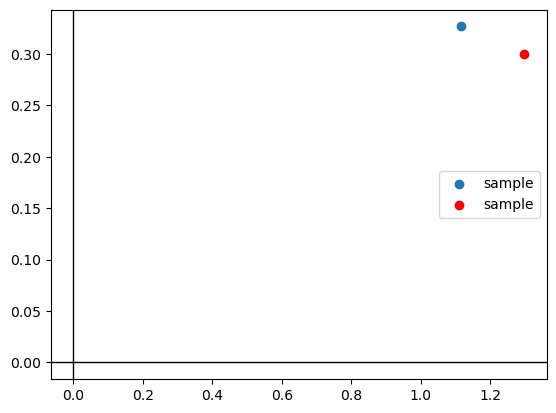

In [45]:
fig, ax = plt.subplots()
view_lim = 2
# ax.set_facecolor("#0e1117")

plt.axhline(0, color='k', linewidth=1)
plt.axvline(0, color='k', linewidth=1)

#
sample = data_dist[sample_idx]
plt.scatter(sample[:,0], sample[:,1], color='tab:blue', label='sample')


x = sample
sigma_t = 0.2
xt = x+torch.randn(x.shape)*sigma_t
plt.scatter(xt[:,0], xt[:,1], color='red', label='sample')



plt.legend()
# plt.xlim([-view_lim, view_lim])
# plt.ylim([-view_lim, view_lim])

In [23]:
#
idx = torch.randint(dataset_size, (1, ))
sample = data_dist[idx]

In [24]:
sample.shape

torch.Size([1, 2])

(-0.05, 1.05, -0.025, 0.525)

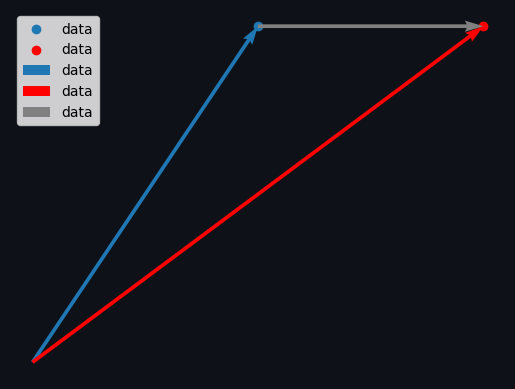

In [27]:
fig, ax = plt.subplots(facecolor="#0e1117")
view_lim = 2
# plt.axis('off')
ax.set_facecolor("#0e1117")

# plt.axhline(0, color='k', linewidth=1)
# plt.axvline(0, color='k', linewidth=1)

vec_a = torch.tensor([0.5,0.5])
vec_b = torch.tensor([1,0.5])
diff = vec_b - vec_a

plt.scatter([vec_a[0]], [vec_a[1]], color='tab:blue', label='data')
plt.scatter([vec_b[0]], [vec_b[1]], color='red', label='data')

plt.quiver([0], [0], [vec_a[0]], [vec_a[1]], color='tab:blue', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )

plt.quiver([0], [0], [vec_b[0]], [vec_b[1]], color='red', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )

plt.quiver([vec_a[0]], [vec_a[1]], [diff[0]], [diff[1]], color='gray', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )


plt.legend()
# plt.xlim([-view_lim, view_lim])
# plt.ylim([-view_lim, view_lim])

# # plt.axis('off')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.axis('off')

In [ ]:
fig, ax = plt.subplots(facecolor="#0e1117")
view_lim = 2
# plt.axis('off')
ax.set_facecolor("#0e1117")

# plt.axhline(0, color='k', linewidth=1)
# plt.axvline(0, color='k', linewidth=1)

vec_a = torch.tensor([0.5,0.5])
vec_b = torch.tensor([1,0.5])

dist_b
diff = vec_b - vec_a

plt.scatter([vec_a[0]], [vec_a[1]], color='tab:blue', label='data')
plt.scatter([vec_b[0]], [vec_b[1]], color='red', label='data')

plt.quiver([0], [0], [vec_a[0]], [vec_a[1]], color='tab:blue', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )

plt.quiver([0], [0], [vec_b[0]], [vec_b[1]], color='red', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )

plt.quiver([vec_a[0]], [vec_a[1]], [diff[0]], [diff[1]], color='gray', label='data',
        angles='xy', scale_units='xy', scale=1.0,
            )


plt.legend()
# plt.xlim([-view_lim, view_lim])
# plt.ylim([-view_lim, view_lim])

# # plt.axis('off')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.axis('off')

### functions and classes...

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class AttractionField:

    def __init__(self, data_points):
        """
        Initialize with a distribution of data points

        Args:
            data_points: array-like of shape (n_samples, n_features) or list of points
        """
        self.data_points = np.array(data_points)
        if self.data_points.ndim == 1:
            self.data_points = self.data_points.reshape(1, -1)

        self.num_samples = self.data_points.shape[0]


    def compute_attraction(self, test_point):
        """
        Compute the total attraction vector at a test point towards all data points

        Args:
            test_point: array-like, the point at which to compute attraction

        Returns:
            attraction vector (numpy array)
        """
        test_point = np.array(test_point)

        total_attraction = np.zeros_like(test_point, dtype=float)

        for data_point in self.data_points:
            attraction = data_point - test_point
            total_attraction += attraction

        return total_attraction/self.num_samples


    def generate_field(self, x_range=(-4,4), y_range=(-4,4), resolution=20):
        """
        Generate a vector field showing attraction at grid points
        """
        x = np.linspace(*x_range, resolution)
        y = np.linspace(*y_range, resolution)

        X, Y = np.meshgrid(x, y)

        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                pt = np.array([X[i,j], Y[i,j]])
                vec = self.compute_attraction(pt)

                U[i,j] = vec[0]
                V[i,j] = vec[1]

        return X, Y, U, V


    def plot_vector_field(self, X, Y, U, V, figsize=(6,6)):
        """
        Plot the vector field
        """
        fig, ax = plt.subplots(figsize=figsize)

        fig.patch.set_facecolor("black")
        ax.set_facecolor("black")

        magnitude = np.sqrt(U**2 + V**2) + 1e-6
        U_norm = U / magnitude
        V_norm = V / magnitude

        ax.quiver(
            X, Y,
            U_norm, V_norm,
            magnitude,
            color='cyan',
            scale=30,
            width=0.005
        )

        ax.scatter(
            self.data_points[:, 0],
            self.data_points[:, 1],
            color="red",
            s=150,
            linewidth=1.5,
            zorder=5
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")

        plt.show()


    def plot_attraction_at_point(
            self, test_point, attraction_vector=None,
            figsize=(6,6), arrow_size=1,
            **kwargs):
        """
        Visualize data distribution, test point, and attraction vector only.

        Args:
            test_point: array-like, the test point location
            attraction_vector: array-like, optional precomputed attraction vector
            x_range: tuple or None, x-axis limits; auto-computed if None
            y_range: tuple or None, y-axis limits; auto-computed if None
            figsize: tuple, figure size
            arrow_fraction: float in (0, 1], target arrow length as fraction of plot width
        """
        test_point = np.array(test_point, dtype=float)
        if attraction_vector is None:
            attraction_vector = self.compute_attraction(test_point)
        else:
            attraction_vector = np.array(attraction_vector, dtype=float)
        vec_norm = np.linalg.norm(attraction_vector)

        arrow_size = kwargs['arrow'].pop('size', 1)
        display_vector = arrow_size*(attraction_vector / vec_norm)

        figsize = kwargs.get('figsize', (4,4))
        fig, ax = plt.subplots(figsize=figsize)
        width = kwargs.get('width', 10)
        fig.patch.set_facecolor("black")
        ax.set_facecolor("black")

        ax.scatter(
            self.data_points[:, 0],
            self.data_points[:, 1],
            **kwargs['dist_points_args'],
        )

        ax.scatter(
            test_point[0],
            test_point[1],
            **kwargs['test_point_args'],
        )
        ax.quiver(
            test_point[0], test_point[1],
            display_vector[0], display_vector[1],
            scale=width,
            label="Attraction vector",
            **kwargs['arrow'],
        )
        ax.set_xlim(-width//2, width//2)
        ax.set_ylim(-width//2, width//2)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        # ax.legend(loc='upper right', facecolor='gray', edgecolor='white')

        plt.show()

        return fig, ax
    


import numpy as np


def sample_gmm(n_samples, means, covs, weights):
    """
    Sample from a Gaussian mixture model.

    Parameters
    ----------
    n_samples : int
    means : list of (2,) arrays
    covs : list of (2,2) arrays
    weights : list of floats (must sum to 1)

    Returns
    -------
    samples : (n_samples, 2)
    """

    means = np.array(means)
    weights = np.array(weights)

    n_components = len(weights)

    # choose which component each sample comes from
    component_ids = np.random.choice(n_components, size=n_samples, p=weights)

    samples = np.zeros((n_samples, 2))

    for k in range(n_components):
        idx = component_ids == k
        n_k = idx.sum()

        if n_k > 0:
            samples[idx] = np.random.multivariate_normal(
                means[k], covs[k], size=n_k
            )

    return samples

Attraction at test point [0, -5]: [5.99640908 7.31608958]


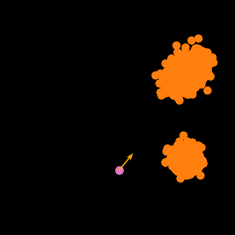

(<Figure size 288x288 with 1 Axes>, <AxesSubplot:>)

In [2]:
# Example with multiple data points
# data_distribution = [
#     [1.5, 1.0],
#     [-1.0, -0.5],
#     [0.5, -1.5]
# ]

# mean = np.array([2.0, -1.0])
# cov = np.array([
#     [0.5, 0.3],
#     [0.3, 0.3]
# ])

# data_distribution = np.random.multivariate_normal(mean, cov, size=500)

means = [
    [6, -4],
    [6, 4],
    # [0, 3]
]

covs = [
    [[0.4, 0], [0, 0.4]],
    [[0.6, 0.2], [0.2, 0.6]],
    # [[0.3, 0], [0, 0.8]]
]

weights = [0.2, 0.8]

data_distribution = sample_gmm(2000, means, covs, weights)

colors_dict = {
    'data_points': "#FF7F0E",
    'test_point': "#E377C2",
    'gen_points': "#17BECF",   
    'attraction': "#FFB000",
    'repulsion': "#00BFFF",
    'resultant': "#FFFFFF",
}


kwargs = {
    'width': 20,
    'figsize': (4, 4),
    'arrow': {
        'size': 2,
        'width': 0.006,
        'headwidth': 4,
        'headlength': 6,
        'zorder': 7,
        'color': colors_dict['attraction'],
    },
    'dist_points_args': {
        'color': colors_dict['data_points'],
        's': 50,
        'linewidth': 1.2,
        'zorder': 5,
        'label': "Data points"
    },
    'test_point_args': {
        'color': colors_dict['test_point'], #"#17BECF", #"#E377C2" ,
        's': 100,
        'marker': 'o',
        'edgecolors': "black",
        'linewidth': 1.3,
        'zorder': 6,
        'label': "Test point"
    },
}

field = AttractionField(data_points=data_distribution)
# Compute attraction at a specific test point
test_point = [0, -5]
attraction = field.compute_attraction(test_point)
print(f"Attraction at test point {test_point}: {attraction}")

# Visualize only data points, test point, and scaled attraction vector
field.plot_attraction_at_point(
    test_point=test_point,
    attraction_vector=attraction,
    **kwargs,
)

### drifting field implementation...

In [317]:
from matplotlib.lines import Line2D

def plot_batch_of_gen_data(ax, data_dist, gen_dist, view_lim, colors_dict):
    ax.set_facecolor(colors_dict['axis'])
    ax.set_aspect('equal', adjustable='box')

    # data dist
    ax.scatter(data_dist[:,0], data_dist[:,1], color=colors_dict['data_pts'], label='Data')
    data_mean = data_dist.mean(0)
    ax.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
        color=colors_dict['mean_color'], 
        label='Data mean'
        )

    # gen dist...and field
    ax.scatter(gen_dist[:,0], gen_dist[:,1], color=colors_dict['gen_pts'], label='Generated')
    ax.quiver(gen_dist[:,0], gen_dist[:,1], field[:,0], field[:,1], 
        color=colors_dict['field'],
        # alpha=0.9, 
        width=0.01,
        )

    ax.set_xlim([-view_lim, view_lim])
    ax.set_ylim([-view_lim, view_lim])
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Local drift for generated samples")


def plot_global_field(ax, mean_centers, data_dist, gen_dist, view_lim, colors_dict):
    ax.set_facecolor(colors['axis'])
    ax.set_aspect('equal', adjustable='box')

    # grid field...
    ax.quiver(grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], 
        color=colors['field'],
        alpha=0.9, 
        width=0.006,

        )

    # data dist
    # ax.scatter(
    #     mean_centers[:,0], mean_centers[:,1], 
    #     color=colors['data_pts'], 
    #     # s=65, linewidth=0.6, 
    #     label='Modes'
    #     )
    ax.scatter(data_dist[:,0], data_dist[:,1], color=colors_dict['data_pts'], label='Data')
    data_mean = data_dist.mean(0)
    ax.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
        color=colors['mean_color'], 
        label='Mean'
        )

    ax.set_xlim([-view_lim, view_lim])
    ax.set_ylim([-view_lim, view_lim])
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(f"Global attraction field")



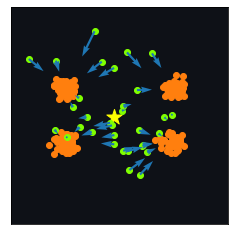

<Figure size 432x288 with 0 Axes>

In [344]:
fig, ax = plt.subplots()
plot_batch_of_gen_data(ax, data_dist, gen_dist, view_lim, colors)
ax.set_title("")
plt.show()
plt.savefig("drifting.png")

Text(0.5, 0.74, 't = 0.1')

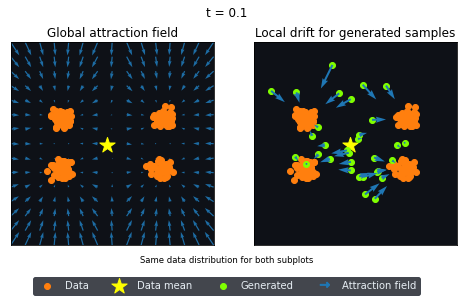

In [338]:
colors = {
    'fig': "#0e1117",
    'fig': "#ffffff",
    'axis': "#0e1117",

    'field': "tab:blue",
    'data_pts': "tab:orange",   # soft yellow
    'gen_pts': "#80ff00",       # neon green
    'mean_color': "yellow",   # almost white-teal


}
figsize=(8,8)
fig, axes = plt.subplots(1,2,figsize=figsize, 
    facecolor=colors['fig']
    )

ax = axes[0]
plot_global_field(ax, mean_centers, data_dist, gen_dist, view_lim, colors)
ax = axes[1]
plot_batch_of_gen_data(ax, data_dist, gen_dist, view_lim, colors)


arrow_handle = Line2D(
    [0], [0],
    color=colors['field'],
    lw=2,
    marker=r'$\rightarrow$',
    markersize=10,
    linestyle='None',
    label="Attraction field"
)
handles, labels = axes[1].get_legend_handles_labels()
handles.append(arrow_handle)
labels.append("Attraction field")

# leg = fig.legend(handles, labels, loc="upper center", ncol=4, frameon=True)

leg = fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.28),  # (x, y) in figure coords
    ncol=4
)

leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_edgecolor("#2a2f3a")

for text in leg.get_texts():
    text.set_color("#e6edf3")

fig.text(0.5, 0.30, "Same data distribution for both subplots", 
         ha="center", va="center", fontsize=8.5, color="black")

fig.suptitle(f"t = {temp}", y=0.74, fontsize=12)

In [ ]:
colors = {
    'fig': "#0e1117",
    'axis': "#0e1117",

    'grid_lines': "#2a2f3a",
    'grid_field': "#5c6370",   # brighter → more visible but still muted

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "yellow",   # almost white-teal
    'mean_edgecolor': "yellow",

    # 'gen_pts': "#f5a97f",

    # 'field': "#b48cf2",
    # 'field': "cyan",
    'field': "tab:blue",
    # 'field': "#f72585",

    # 'data_pts': "#ffd166",   # soft yellow
    # 'gen_pts': "#ef476f",    # coral red

    'data_pts': "tab:orange",   # soft yellow
    'gen_pts': "cyan",    # coral red

}



fig, ax = plt.subplots(facecolor=colors['fig'])




In [ ]:
def compute_drift(
        y_pos, 
        # y_neg, 
        x
    ):
    # targets = torch.cat([y_pos, y_neg])
    G = y_pos.shape[0]
    dists = torch.cdist(x, targets)
    norm_kernel_row = F.softmax(dists, dim=1)
    norm_kernel_col = F.softmax(dists, dim=0)
    normalized_kernel = torch.sqrt(norm_kernel_row*norm_kernel_col)

    diff = targets[None,...] - x[:,None]

    v_pos =  (normalized_kernel[:,None,:G]@diff[:,:G]).squeeze(1)
    v_neg =  (normalized_kernel[:,None, G:]@diff[:,G:]).squeeze(1)
    v = (v_pos - v_neg)
    return v/torch.norm(v), v_pos/torch.norm(v_pos), v_neg/torch.norm(v_neg)
    


In [65]:
mean = data_dist.mean(0)

In [66]:
mean.shape

torch.Size([2])

(-2.0, 2.0, -2.0, 2.0)

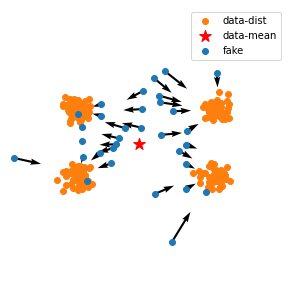

In [189]:
batch_size = 32
x = torch.randn(batch_size,2)*0.6
temp=0.1
field = compute_mean_shift(data_dist, x, temp)

fig, ax = plt.subplots(figsize=(5,5))
plt.quiver(x[:,0], x[:,1], field[:,0], field[:,1])

plt.scatter(data_dist[:,0], data_dist[:,1], color='tab:orange', label='data-dist')
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], color='red', marker='*', s=150, label='data-mean')
plt.scatter(x[:,0], x[:,1], color='tab:blue', label='fake')
plt.legend()

view_lim = 2
plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])
plt.axis('off')

(-2.0, 2.0, -2.0, 2.0)

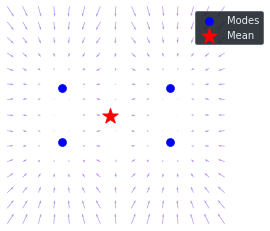

In [187]:
colors = {
    # 'fig': "#0e1117",
    # 'axis': "#0e1117",
    'fig': "#ffffff",
    'axis': "#ffffff",

    'grid_lines': "#222833",
    'grid_field': "#6b7a99",

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "red",   # almost white-teal
    'mean_edgecolor': "red",

    # 'gen_pts': "#f5a97f",

    'field': "black",

    'data_pts': "blue",   # soft yellow
    'gen_pts': "tab:orange",    # coral red
}


fig, ax = plt.subplots(facecolor=colors['fig'])
ax.set_facecolor(colors['axis'])
# ax.grid(True, color=colors['grid_lines'], linestyle="--", linewidth=0.7, alpha=0.8)
ax.set_aspect('equal', adjustable='box')

# grid field...
plt.quiver(
    grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], 
    # color=colors['grid_field'], alpha=0.55,
    
    width=0.003, scale=30, color='#b48cf2',
    )

# data dist
plt.scatter(
    mean_centers[:,0], mean_centers[:,1], 
    color=colors['data_pts'], 
    s=65, linewidth=0.6, 
    label='Modes'
    )
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
    color=colors['mean_color'], 
    edgecolor=colors['mean_edgecolor'],
    label='Mean'
    )


# leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
# leg.get_frame().set_facecolor("#141821")
# leg.get_frame().set_alpha(0.85)
leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("#5c6370")

for text in leg.get_texts():
    text.set_color("#e6edf3")

plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])
plt.axis('off')

In [116]:
# data distributions...
batch_size = 32
mean_centers = torch.tensor([ [1, 0.5], 
                            [1, -0.5], 
                            [-1, 0.5], 
                            [-1, -0.5]]
                            )
data_dist = mean_centers[torch.randint(4, (200, ))] + torch.randn(200, 2)*0.1
gen_dist = torch.randn(batch_size,2)*0.6


def compute_mean_shift(y_pos, x, temp=1):
    vector_diff = y_pos[None] - x[:,None]
    similarity = - torch.cdist(x, y_pos)/temp
    normalized_kernel = F.softmax(similarity, dim=1)
    Vp = (normalized_kernel[:,None]@vector_diff).squeeze()
    return Vp

In [258]:
temp=0.1

# background 
view_lim = 2
n_grid_pts = 15
x_coor = torch.linspace(-view_lim, view_lim, n_grid_pts)
y_coor = torch.linspace(-view_lim, view_lim, n_grid_pts)
X, Y = torch.meshgrid(x_coor, y_coor, indexing='ij')
grid_pts = torch.stack([X.flatten(), Y.flatten()], dim=1)


# fields...
field = compute_mean_shift(data_dist, gen_dist, temp)
grid_field = compute_mean_shift(data_dist, grid_pts, temp)

(-2.0, 2.0)

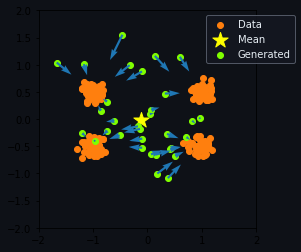

In [256]:
colors = {
    'fig': "#0e1117",
    'axis': "#0e1117",

    'grid_lines': "#2a2f3a",
    'grid_field': "#5c6370",   # brighter → more visible but still muted

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "yellow",   # almost white-teal
    'mean_edgecolor': "yellow",

    # 'gen_pts': "#f5a97f",

    # 'field': "cyan",
    'field': "#f72585",
    'field': "tab:blue",

    # 'data_pts': "#ffd166",   # soft yellow
    # 'gen_pts': "#ef476f",    # coral red

    'data_pts': "tab:orange",   # soft yellow
    # 'gen_pts': "tab:blue",    # coral red
    # 'gen_pts': "#f72585",
    'gen_pts': "#80ff00",       # neon green
    # 'gen_pts': "#9d4edd",
    # 'gen_pts': "#9d4edd",

}



fig, ax = plt.subplots(facecolor=colors['fig'])
ax.set_facecolor(colors['axis'])
# ax.grid(True, color=colors['grid_lines'], linestyle="--", linewidth=0.7, alpha=0.8)
ax.set_aspect('equal', adjustable='box')

# grid field...
# plt.quiver(grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], color=colors['grid_field'], alpha=0.4)

# data dist
plt.scatter(data_dist[:,0], data_dist[:,1], color=colors['data_pts'], label='Data')
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
    color=colors['mean_color'], 
    edgecolor=colors['mean_edgecolor'],
    label='Mean'
    )

# gen dist...and field
plt.scatter(gen_dist[:,0], gen_dist[:,1], color=colors['gen_pts'], label='Generated')
plt.quiver(gen_dist[:,0], gen_dist[:,1], field[:,0], field[:,1], 
    color=colors['field'],
    # alpha=0.9, 
    width=0.01,
    )

# leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
# leg.get_frame().set_facecolor("#141821")
# leg.get_frame().set_alpha(0.85)
leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("#5c6370")

for text in leg.get_texts():
    text.set_color("#e6edf3")


plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])


(-2.0, 2.0)

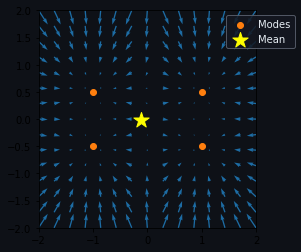

In [263]:
colors = {
    'fig': "#0e1117",
    'axis': "#0e1117",

    'grid_lines': "#2a2f3a",
    'grid_field': "#5c6370",   # brighter → more visible but still muted

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "yellow",   # almost white-teal
    'mean_edgecolor': "yellow",

    # 'gen_pts': "#f5a97f",

    # 'field': "#b48cf2",
    # 'field': "cyan",
    'field': "tab:blue",
    # 'field': "#f72585",

    # 'data_pts': "#ffd166",   # soft yellow
    # 'gen_pts': "#ef476f",    # coral red

    'data_pts': "tab:orange",   # soft yellow
    'gen_pts': "cyan",    # coral red

}



fig, ax = plt.subplots(facecolor=colors['fig'])
ax.set_facecolor(colors['axis'])
# ax.grid(True, color=colors['grid_lines'], linestyle="--", linewidth=0.7, alpha=0.8)
ax.set_aspect('equal', adjustable='box')

# grid field...
plt.quiver(grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], 
    # color=colors['field'],
    color=colors['field'],
    alpha=0.9, 
    width=0.006,

    )

# data dist
# plt.scatter(data_dist[:,0], data_dist[:,1], color=colors['data_pts'], label='Data')
plt.scatter(
    mean_centers[:,0], mean_centers[:,1], 
    color=colors['data_pts'], 
    # s=65, linewidth=0.6, 
    label='Modes'
    )
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
    color=colors['mean_color'], 
    edgecolor=colors['mean_edgecolor'],
    label='Mean'
    )

# gen dist...and field
# plt.scatter(gen_dist[:,0], gen_dist[:,1], color=colors['gen_pts'], label='Generated')
# plt.quiver(gen_dist[:,0], gen_dist[:,1], field[:,0], field[:,1], 
#     color=colors['field'],
#     alpha=0.9, width=0.005,
#     )

# leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
# leg.get_frame().set_facecolor("#141821")
# leg.get_frame().set_alpha(0.85)
leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("#5c6370")

for text in leg.get_texts():
    text.set_color("#e6edf3")


plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])


(-2.0, 2.0)

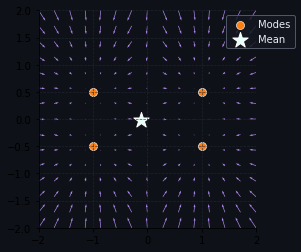

In [174]:
colors = {
    'fig': "#0e1117",
    'axis': "#0e1117",
    # 'fig': "#ffffff",
    # 'axis': "#ffffff",

    'grid_lines': "#222833",
    'grid_field': "#6b7a99",

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "#e6fff9",   # almost white-teal
    'mean_edgecolor': "#ffffff",

    # 'gen_pts': "#f5a97f",

    'field': "#b48cf2",

    'data_pts': "tab:orange",   # soft yellow
    'gen_pts': "cyan",    # coral red
}


fig, ax = plt.subplots(facecolor=colors['fig'])
ax.set_facecolor(colors['axis'])
ax.grid(True, color=colors['grid_lines'], linestyle="--", linewidth=0.7, alpha=0.8)
ax.set_aspect('equal', adjustable='box')

# grid field...
plt.quiver(
    grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], 
    # color=colors['grid_field'], alpha=0.55,
    
    width=0.003, scale=30, color='#b48cf2',
    )

# data dist
plt.scatter(
    mean_centers[:,0], mean_centers[:,1], 
    color=colors['data_pts'], 
    s=65, edgecolor="#ffffff", linewidth=0.6, 
    label='Modes'
    )
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
    color=colors['mean_color'], 
    edgecolor=colors['mean_edgecolor'],
    label='Mean'
    )


# leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
# leg.get_frame().set_facecolor("#141821")
# leg.get_frame().set_alpha(0.85)
leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("#5c6370")

for text in leg.get_texts():
    text.set_color("#e6edf3")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])


(-2.0, 2.0)

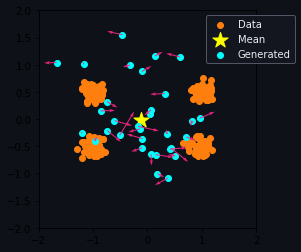

In [199]:
colors = {
    'fig': "#0e1117",
    'axis': "#0e1117",

    'grid_lines': "#2a2f3a",
    'grid_field': "#5c6370",   # brighter → more visible but still muted

    # data dist and data mean
    # 'data_pts': "#8bd5ca",
    'mean_color': "yellow",   # almost white-teal
    'mean_edgecolor': "yellow",

    # 'gen_pts': "#f5a97f",

    # 'field': "#b48cf2",
    'field': "#f72585",

    # 'data_pts': "#ffd166",   # soft yellow
    # 'gen_pts': "#ef476f",    # coral red

    'data_pts': "tab:orange",   # soft yellow
    'gen_pts': "cyan",    # coral red

}



fig, ax = plt.subplots(facecolor=colors['fig'])
ax.set_facecolor(colors['axis'])
# ax.grid(True, color=colors['grid_lines'], linestyle="--", linewidth=0.7, alpha=0.8)
ax.set_aspect('equal', adjustable='box')

# grid field...
# plt.quiver(grid_pts[:,0], grid_pts[:,1], grid_field[:,0], grid_field[:,1], color=colors['grid_field'], alpha=0.4)

# data dist
plt.scatter(data_dist[:,0], data_dist[:,1], color=colors['data_pts'], label='Data')
data_mean = data_dist.mean(0)
plt.scatter([data_mean[0]], [data_mean[1]], marker='*', s=260, linewidths=1.0,
    color=colors['mean_color'], 
    edgecolor=colors['mean_edgecolor'],
    label='Mean'
    )

# gen dist...and field
plt.scatter(gen_dist[:,0], gen_dist[:,1], color=colors['gen_pts'], label='Generated')
plt.quiver(gen_dist[:,0], gen_dist[:,1], field[:,0], field[:,1], 
    color=colors['field'],
    alpha=0.9, width=0.005,
    )

# leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
# leg.get_frame().set_facecolor("#141821")
# leg.get_frame().set_alpha(0.85)
leg = plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
leg.get_frame().set_facecolor("#141821")
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_edgecolor("#5c6370")

for text in leg.get_texts():
    text.set_color("#e6edf3")


plt.xlim([-view_lim, view_lim])
plt.ylim([-view_lim, view_lim])


In [93]:
grid_pts.shape

torch.Size([10000, 2])

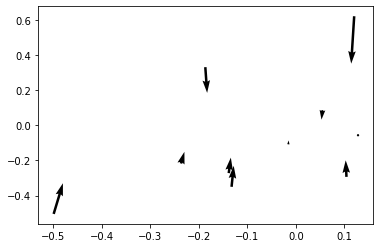

In [44]:
torch.randint(4, (10,))

tensor([2, 1, 1, 3, 2, 3, 2, 3, 2, 1])

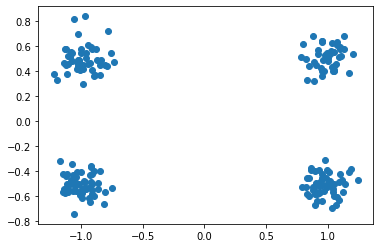

In [29]:
Vp.shape

torch.Size([32, 2])

In [23]:
normalized_kernel.shape

torch.Size([32, 100])

In [22]:
vector_diff.shape

torch.Size([32, 100, 2])

In [3]:
diffs = torch.cdist(y_pos, x)


In [4]:
diffs.shape

torch.Size([100, 32])

In [96]:
normalized_kernel.shape

torch.Size([10, 200])

In [118]:
v_pos.shape

torch.Size([1, 1, 2])

In [151]:
n_mixtures = 2
mixture_means = torch.tensor([[0.5, -0.5],
                    [0.5, 0.5]])
n_samples = 100
idx = torch.randint(0, n_mixtures, (n_samples, ))
y_pos = mixture_means[idx]  + torch.randn(n_samples, 2)*0.1
negative_mean = torch.tensor([-0.5, 0])
y_neg = negative_mean + torch.randn(n_samples, 2)*0.2



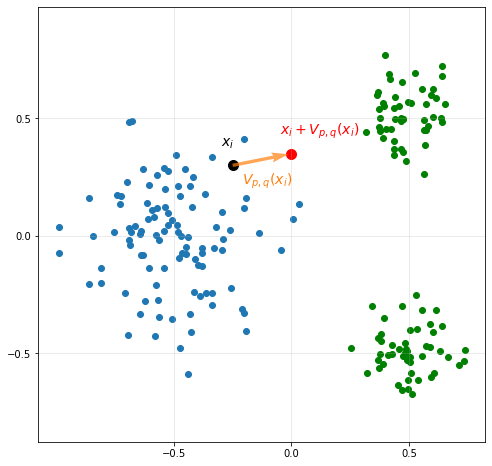

In [188]:
x_i = torch.tensor([-0.25, 0.3], dtype=torch.float32).unsqueeze(0)
v = torch.tensor([0.25, 0.05], dtype=torch.float32).unsqueeze(0)

x_next = x_i + v
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(y_pos[:,0], y_pos[:,1], color='green')
ax.scatter(y_neg[:,0], y_neg[:,1], color='tab:blue')

ax.scatter(x_i[:,0], x_i[:,1], color='k', s=100)
ax.scatter(x_next[:,0], x_next[:,1], color='red', s=100)

plt.quiver(x_i[:,0], x_i[:,1], v[:, 0], v[:, 1],
           color='tab:orange', alpha=0.7, scale=2, 
           )


# label the point x_i
ax.text(x_i[0,0].item()-0.05, x_i[0,1].item()+0.08,
        r"$x_i$",  
        fontsize=14
)
ax.text(x_next[0,0].item()-0.05, x_next[0,1].item()+0.08,
        r"$x_i + V_{p,q}(x_i)$", color='red',
        fontsize=14,
        )

# label the vector field V_{p,q}(x_i)
ax.text(x_i[0,0].item() + 0.04,
        x_i[0,1].item() -0.08,
        r"$V_{p,q}(x_i)$",
        fontsize=14, color='tab:orange'
        )

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_xticks([-0.5, 0.0, 0.5])
ax.set_yticks([-0.5, 0.0, 0.5])
plt.axis('equal')
plt.grid(True, alpha=0.3)


In [43]:
x = torch.randn(10,2)

print(f"y_pos shape: {y_pos.shape}")
print(f"y_neg shape: {y_neg.shape}")

print(x.shape)

y_pos shape: torch.Size([100, 2])
y_neg shape: torch.Size([100, 2])
torch.Size([10, 2])


In [ ]:
de

In [ ]:
targets = torch.cat([y_pos, y_neg])
G = y_pos.shape[0]
dists = torch.cdist(x, targets)
norm_kernel_row = F.softmax(dists, dim=1)
norm_kernel_col = F.softmax(dists, dim=0)
normalized_kernel = torch.sqrt(norm_kernel_row*norm_kernel_col)

diff = targets[None,...] - x[:,None]

# v_pos =  normalized_kernel[:,None,:G]@diff[:,:G]
# v_neg =  normalized_kernel[:,None, G:]@diff[:,G:]
# v = (v_pos - v_neg).squeeze()

In [ ]:
F.softmax(dists, dim=1)

In [89]:
dists.shape

torch.Size([10, 200])

In [67]:
v.shape

torch.Size([10, 2])

In [56]:
normalized_kernel.shape

torch.Size([10, 200])

In [57]:
diff.shape

torch.Size([10, 200, 2])

In [63]:
v_pos.shape

torch.Size([10, 1, 2])

In [54]:
v.shape

torch.Size([10, 10, 2])

In [52]:
diff.shape

torch.Size([10, 200, 2])

In [50]:
targets.shape

torch.Size([200, 2])

In [47]:
dists.shape

torch.Size([10, 200])

In [49]:
normalized_kernel.shape

torch.Size([10, 200])

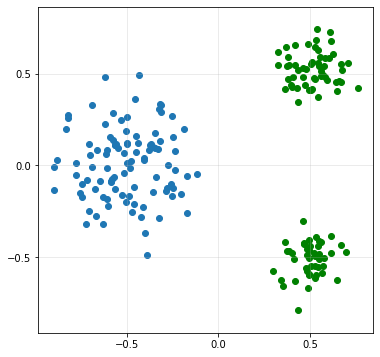

In [41]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(y_pos[:,0], y_pos[:,1], color='green')
ax.scatter(y_neg[:,0], y_neg[:,1], color='tab:blue')

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_xticks([-0.5, 0.0, 0.5])
ax.set_yticks([-0.5, 0.0, 0.5])
plt.axis('equal')
plt.grid(True, alpha=0.3)


In [6]:
means[1]

tensor([0.5000, 0.2500])

In [ ]:

    y_pos = y_pos.unsqueeze(0).unsqueeze(2)
    y_neg = y_neg.unsqueeze(0).unsqueeze(1)
    x = x.unsqueeze(1).unsqueeze(2)
    diff = y_pos - y_neg

    k_pos = F.softmax(torch.sqrt((y_pos - x)**2), dim=1) 
    k_neg = F.softmax(torch.sqrt((y_neg - x)**2), dim=2)

    v = (k_pos*k_neg*diff).mean(1).mean(1)

In [68]:
def plot_attraction_at_point(
        x, v, y_pos=None, y_neg=None,
        figsize=(6,6), arrow_size=1,
        **kwargs
        ):

        arrow_size = kwargs['arrow'].pop('size', 1)
        display_vector = arrow_size*v/torch.norm(v, dim=1, keepdim=True)
        figsize = kwargs.get('figsize', (4,4))
        fig, ax = plt.subplots(figsize=figsize)
        width = kwargs.get('width', 10)
        fig.patch.set_facecolor("black")
        ax.set_facecolor("black")

        if y_pos is not None:
            ax.scatter(
                y_pos[:, 0],
                y_pos[:, 1],
                **kwargs['pos_dist'],
            )
        
        if y_neg is not None:
            ax.scatter(
                y_neg[:, 0],
                y_neg[:, 1],
                **kwargs['neg_dist'],
            )

        ax.scatter(
            x[:, 0],
            x[:, 1],
            **kwargs['test_point'],
        )
        ax.quiver(
            x[:,0], x[:, 1],
            display_vector[:,0], display_vector[:,1],
            scale=width,
            label="Attraction vector",
            **kwargs['arrow'],
        )
        ax.set_xlim(-width//2, width//2)
        ax.set_ylim(-width//2, width//2)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        # ax.legend(loc='upper right', facecolor='gray', edgecolor='white')

        plt.show()

        return fig, ax

In [51]:
torch.norm(v, dim=1).shape

torch.Size([1])

In [69]:
colors_dict = {
    'pos_dist': "#FF7F0E",
    'test_point': "#E377C2",
    'neg_dist': "#17BECF",   
    'attraction': "#FFB000",
    'repulsion': "#00BFFF",
    'resultant': "#FFFFFF",
}


kwargs = {
    'width': 20,
    'figsize': (4, 4),
    'arrow': {
        'size': 2.5,
        'width': 0.006,
        'headwidth': 4,
        'headlength': 6,
        'zorder': 7,
        'color': colors_dict['attraction'],
    },
    'pos_dist': {
        'color': colors_dict['pos_dist'],
        's': 50,
        'linewidth': 1.2,
        'zorder': 5,
        'label': "Data points"
    },
    'neg_dist': {
        'color': colors_dict['neg_dist'],
        's': 50,
        'linewidth': 1.2,
        'zorder': 5,
        'label': "Data points"
    },
    'test_point': {
        'color': colors_dict['test_point'], #"#17BECF", #"#E377C2" ,
        's': 100,
        'marker': 'o',
        'edgecolors': "black",
        'linewidth': 1.3,
        'zorder': 6,
        'label': "Test point"
    },
}

In [78]:
def attr_field(y, x):
    diff = y.unsqueeze(0) - x.unsqueeze(1)
    k = F.softmax(torch.sqrt(diff**2), dim=1)
    V = torch.mean(k*diff, dim=1)
    return V

def drift_field_separable(y_pos, y_neg, x):
    v_pos = attr_field(y_pos, x)
    v_neg = attr_field(y_neg, x)
    return v_pos - v_neg

def drift_field(y_pos, y_neg, x):

    y_pos = y_pos.unsqueeze(0).unsqueeze(2)
    y_neg = y_neg.unsqueeze(0).unsqueeze(1)
    x = x.unsqueeze(1).unsqueeze(2)
    diff = y_pos - y_neg

    k_pos = F.softmax(torch.sqrt((y_pos - x)**2), dim=1) 
    k_neg = F.softmax(torch.sqrt((y_neg - x)**2), dim=2)

    v = (k_pos*k_neg*diff).mean(1).mean(1)
    return v


In [ ]:
x.unsqueeze()

torch.Size([1, 2])

In [79]:
y_pos = torch.tensor(data_distribution)
x = torch.tensor(test_point).unsqueeze(0)

y_neg = torch.randn(y_pos.shape[0], 2) + torch.tensor([-5, 0])

v_pos = attr_field(y_pos, x)
v_neg = attr_field(y_neg, x)

v = v_pos - v_neg

In [81]:
v

tensor([[0.0063, 0.0018]], dtype=torch.float64)

In [83]:
v = drift_field(y_pos, y_neg, x)
v

tensor([[3.1733e-06, 9.0959e-07]], dtype=torch.float64)

In [86]:
print(f"y_pos shape: {y_pos.shape}")
print(f"y_neg shape: {y_neg.shape}")
print(f"x shape: {x.shape}") 

y_pos shape: torch.Size([2000, 2])
y_neg shape: torch.Size([2000, 2])
x shape: torch.Size([1, 2])


In [87]:
y_pos = y_pos.unsqueeze(0).unsqueeze(2)
y_neg = y_neg.unsqueeze(0).unsqueeze(1)
x = x.unsqueeze(1).unsqueeze(2)


In [88]:
print(f"y_pos shape: {y_pos.shape}")
print(f"y_neg shape: {y_neg.shape}")
print(f"x shape: {x.shape}") 

y_pos shape: torch.Size([1, 2000, 1, 2])
y_neg shape: torch.Size([1, 1, 2000, 2])
x shape: torch.Size([1, 1, 1, 2])


In [89]:
diff = y_pos - y_neg

In [90]:
diff.shape

torch.Size([1, 2000, 2000, 2])

In [91]:

k_pos = F.softmax(torch.sqrt((y_pos - x)**2), dim=1) 
k_neg = F.softmax(torch.sqrt((y_neg - x)**2), dim=2)

v = (k_pos*k_neg*diff).mean(1).mean(1)


In [96]:
(k_pos*k_neg*diff).mean(1).mean(1).shape

torch.Size([1, 2])

In [93]:
y_pos.shape

torch.Size([1, 2000, 1, 2])

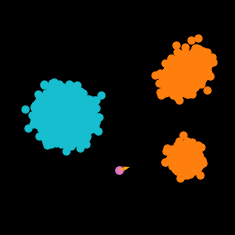

(<Figure size 288x288 with 1 Axes>, <AxesSubplot:>)

In [76]:

# v = attr_field(y_neg, x)

plot_attraction_at_point(
    x, v, y_pos=y_pos, y_neg=y_neg,
    **kwargs,
)

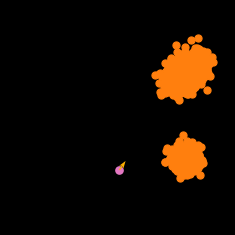

(<Figure size 288x288 with 1 Axes>, <AxesSubplot:>)

In [29]:
# Visualize only data points, test point, and scaled attraction vector
field.plot_attraction_at_point(
    test_point=test_point,
    attraction_vector=V.numpy().squeeze(),
    **kwargs,
)

In [27]:
V

tensor([[0.0033, 0.0048]], dtype=torch.float64)

In [23]:
x.shape

torch.Size([1, 2])

In [24]:
y.shape

torch.Size([2000, 2])

In [17]:
V.shape

torch.Size([32, 2])

In [ ]:
kernel = torch.norm(diff)

torch.Size([32, 100, 2])

In [9]:
x[:, None].shape

torch.Size([32, 1, 2])

In [8]:
y.unsqueeze(0).shape

torch.Size([1, 100, 2])

### official implementation...

In [36]:
gen = torch.randn(3, 2)*0.5 + torch.tensor([1,1])
pos = torch.randn(3, 2)*0.5

targets = torch.cat([gen, pos], dim=0)
G = gen.shape[0]


In [37]:
print(f"targets.shape: {targets.shape}")
print(f"gen.shape: {gen.shape}")

targets.shape: torch.Size([6, 2])
gen.shape: torch.Size([3, 2])


In [38]:
gen

tensor([[1.0318, 0.7755],
        [1.0280, 0.8314],
        [0.5622, 1.2055]])

In [39]:
dist = torch.cdist(gen, targets)
dist[:, :G].fill_diagonal_(1e6)  # mask self

tensor([[1.0000e+06, 5.6046e-02, 6.3676e-01],
        [5.6046e-02, 1.0000e+06, 5.9744e-01],
        [6.3676e-01, 5.9744e-01, 1.0000e+06]])

In [40]:
temp = 1
kernel = (-dist/temp).exp()
normalizer = kernel.sum(dim=-1, keepdim=True) * kernel.sum(dim=-2, keepdim=True) # normalize along both dimensions, which we found to slightly improve performance
normalizer = normalizer.clamp_min(1e-12).sqrt() 
normalized_kernel = kernel / normalizer

In [41]:
pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
pos_V = pos_coeff @ targets[G:]

In [45]:
targets[G:].shape

torch.Size([3, 2])

In [44]:
normalized_kernel[:, :G].sum(dim=-1, keepdim=True).shape

torch.Size([3, 1])

In [42]:
normalized_kernel[:, G:].shape

torch.Size([3, 3])

In [43]:
pos_V.shape

torch.Size([3, 2])

In [32]:
normalized_kernel.shape

torch.Size([2, 4])

In [26]:
kernel

tensor([[0.0000, 0.7097, 0.1038, 0.2024],
        [0.7097, 0.0000, 0.1423, 0.2648]])

In [15]:
dist

tensor([[1.0000e+06, 3.4285e-01, 2.2649e+00, 1.5977e+00],
        [3.4285e-01, 1.0000e+06, 1.9498e+00, 1.3289e+00]])

In [6]:
dist.shape

torch.Size([100, 200])

In [ ]:
targets = torch.cat([gen, pos], dim=0)
    G = gen.shape[0]

    dist = torch.cdist(gen, targets)
    dist[:, :G].fill_diagonal_(1e6)  # mask self
    kernel = (-dist / temp).exp() # unnormalized kernel

    normalizer = kernel.sum(dim=-1, keepdim=True) * kernel.sum(dim=-2, keepdim=True) # normalize along both dimensions, which we found to slightly improve performance
    normalizer = normalizer.clamp_min(1e-12).sqrt() 
    normalized_kernel = kernel / normalizer

    pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
    pos_V = pos_coeff @ targets[G:]
    neg_coeff = normalized_kernel[:, :G] * normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
    neg_V = neg_coeff @ targets[:G]

    return pos_V - neg_V

### plotting examples...

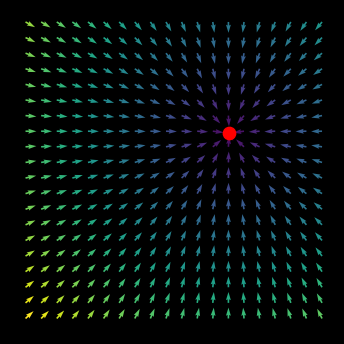

In [38]:
field = AttractionField(data_point=[1.5, 1.0])

X, Y, U, V = field.generate_field()

field.plot_vector_field(X, Y, U, V)

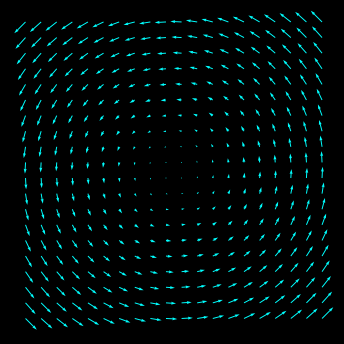

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# create grid
x = np.linspace(-4, 4, 20)
y = np.linspace(-4, 4, 20)
X, Y = np.meshgrid(x, y)

# define vector field
U = -Y
V = X

# create figure
fig, ax = plt.subplots(figsize=(6,6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# plot vector field
ax.quiver(X, Y, U, V, color="cyan")

# remove axes
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.show()

In [ ]:
pt1 = 

In [29]:
locs = np.array([[0, 0],[0 ,0]])
vectors = np.array([
    [1, 1]
    ,[2 ,1]
    ])

In [30]:
vectors[:, 0]

array([1, 2])

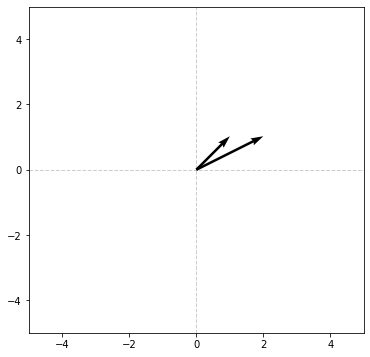

In [32]:
locs = np.array([[0, 0],[0 ,0]])
vectors = np.array([
    [1, 1]
    ,[2 ,1]
    ])
width = 10
fig, ax = plt.subplots(figsize=(6,6))
# fig.patch.set_facecolor("black")
# ax.set_facecolor("black")
# plot vector field
ax.quiver(locs[:, 0], locs[:, 1], vectors[:, 0], vectors[:, 1], color="k", scale=width)
ax.set_xlim(-width//2, width//2)
ax.set_ylim(-width//2, width//2)
ax.axhline(y=0, color='k', ls='--', linewidth=1, alpha=0.2)
ax.axvline(x=0, color='k', ls='--', linewidth=1, alpha=0.2)
# ax.set_xticks([])
# ax.set_yticks([])
plt.show()

In [ ]:
# create figure
fig, ax = plt.subplots(figsize=(6,6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# plot vector field
ax.quiver(X, Y, U, V, color="cyan")

# remove axes
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.show()

In [30]:
data = torch.randn(2, 100)
test_point = torch.tensor([5, 5])

In [31]:
test_point.shape

torch.Size([2])

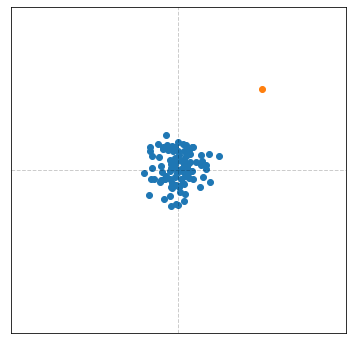

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))

# data distribution...
ax.scatter(test_point[0], test_point[1], color='tab:orange')

# data distribution...
ax.scatter(data[0,:], data[1,:], color='tab:blue')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.axhline(y=0, color='k', ls='--', linewidth=1, alpha=0.2)
ax.axvline(x=0, color='k', ls='--', linewidth=1, alpha=0.2)
ax.set_xticks([])
ax.set_yticks([])
plt.show()